# Notes for myself

Here comes all notes of all the code that I have to look into from 14-03-2025 until now

Content
1. General understanding/notes
1. LDA
1. Epoching
1. shrinkage LDA code & paper
1. Block-Toeplitz LDA code & paper
1. Assignment 6: ERP analysis of a single trial
1. Assignment 7: ERP analysis of multiple trials
1. Simon's code 
1. David's matlab code
1. To be added....
 
To do:
- ~~assignment 2 lda~~ 
- ~~assignment 2: epoching (part 7)~~
- ~~assignment 1 intro~~
- ~~assignment 1 mne (helps with understanding epochs in code)~~
- ~~lecture 2 lda~~
- ~~lecture 6: auc roc part~~ 
- ~~lecture 7~~
- ~~assignment 7 until exercise 4 (very useful)~~
- ...
- ~~read paper single trial analysis and shrinkage lda (Blankertz et al., 2011)~~
- documentation normal lda (shrinkage part is included)
- read paper BT-LDA
- documentation BT-LDA of Jan's github
- documentation BT-LDA (+ adaptation) of Simon
- Look into Simon's auditory aphasia code for adaptation parts
- Look into David's matlab code for adaptation parts
- Read one of Vidaurre's papers completely 


To do later:
- Fully understand AUC and how I am going to use it, together with which statistical test.
- Decide on how exactly the adaptive BT-LDA is going to be compared. How to measure the robustness of updating the classifier all the time
- Pros and cons of high pass filter instead of baseline correction (the latter is not good for BT-LDA)
- understand why in typical ERP analysis pipeline, during preprocessing phase, outlier epochs are marked, then the epoch data structure is removed and we start over with continuous data again, but filter now to a lower requency band to avoid filter artifcats.


## 1. General understanding 

**Difference between trial and epoch**
- Dataset of auditory oddball paradigm: 
    - 3 subjects, each has only one session
    - For each subject, 2 conditions (fast vs slow) for which 80 trials were recorded
- Within 1 trial: 90 stimuli (75 low-pitched non-targets, 15 high-pitched targets)
- So 1 trial = 90 stimuli = 90 epochs 
- Every epoch has a label: target or non-target
- Every trial has eventually also a label: the decoded final decision: target or non-target (based on the results from the 90 epochs)

**AUC-ROC curve**
- lecture 6
- see notebook
- gives a measure of how good the model's direction is (regardless of the bias, bc it gives the scores across all biases)
- it gives a set of models, you have to eventually select a bias to deploy the model

- AUC score is specifically suitable for ERP's, as a model's bias may not play a role (see lecture 7)

**Visualizing ERPs: single responses -> avg responses**
- See notebook
- See slides lecture 7
- **typical ERP analysis pipeline: part 4. online application (slide 23):**
    - 16. record ongoing brain signals, obtain small data packets (of 10 or 40 ms each) with low latency from hardware recording system. we pick them up step by step and stack them up. we keep collecting packets and packets until we have enough packets for a full epoch. Then we can push this into the classifier
    - 17. packet by packet, we can apply the same frequency filtering as done before (e.g. [0.5-16 Hz]). (same preprocessing as in Part 1). Note that before applying a filter to new data, this filter first needs a some wrap up time to get to a good filter state in order to avoid artefacts in the beginning (of the wrapup phase of a digital filter). We store the filter state after filtering each data packet (we don't reset the filter to zero but keep the filter state of the last packet to apply it to a new packet).
    - 18. once all packets of an epoch have arrived: extract features according to Part 2 (for every channel extract time intervals, stack all of those into a feature vector --> a feature representation $x_i$ of that epoch).
    - 19. classify the feature vector with the model trained in step 15. LDA: A positive distance to the hyperplane = target, while a negative distance is non-target. But actually we obtain a numeric value of the LDA, e.g. 0.784. Is that a clear target? we actually can't tell. We would need to know the distribution of targets and non-targets. (When we enforce the outcome of LDA to +1 and -1, then we can say that indeed 0.7 is a good confidence level.)
- Now we have a label of that single stimulus. Can we make a seletion of the symbol/word attended? Not yet, we would need more classification outputs: repeated classification outputs of that same row/column/word. Then we get more and more sure about this decision. 
    - 20. For all epochs belonging to one trial: collect & post-process the classifier outputs to determine the target symbol.
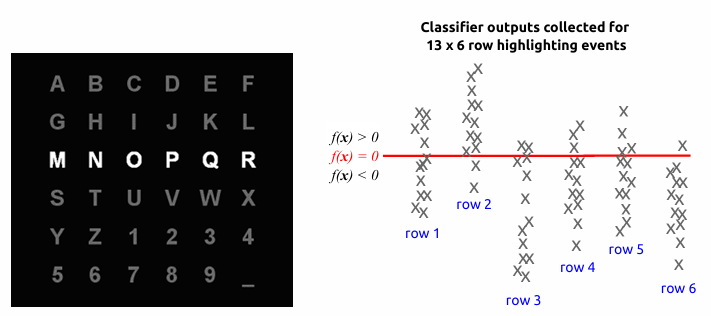

**Why bias is unimportant (and AUC is therefore useful)**

AUC is a good measure for ERP performance bc the bias is not represented in the AUC, but it doesn't matter to us. Looking at the plot, if the classifier is biased (systematically delivers more negative or more positive values), we actually don't care. In order to find out which was the target row, we need to select that row with the highest outputs. whether all of those values are a bit shifted more to the negative or positive, it does not matter. We just take the one that is most positive. So actually, we don't care about the bias. This is very specific for repeated evaluations: before we make a single decision, we collect the output of multiple stimuli. 

- **typical ERP analysis pipeline further**
    - 21. execture resulting control step of that trial (e.g. write a symbol) in final application and show feedback to user
    - 22. Optional: include dynamic stopping of stimulus presentation to shorten a trial
    - 23. Optional: include online adaptation of the classifier to cope with changing distributions

In [7]:
x = 2
y = 5

for i in range(10):
    print("i: ",i)
    if(i<3):
        print("continue")
        continue # skipping everything under here and continue to the next iteration i = ...
    if (x>1):
        print("reached 2nd if statement")
    else:
        print("reached else")

i:  0
continue
i:  1
continue
i:  2
continue
i:  3
reached 2nd if statement
i:  4
reached 2nd if statement
i:  5
reached 2nd if statement
i:  6
reached 2nd if statement
i:  7
reached 2nd if statement
i:  8
reached 2nd if statement
i:  9
reached 2nd if statement


## 2. Understanding LDA (code + mathematics)



- LDA Math 
- implementing LDA from scratch 
- LDA documentation from sklearn

### LDA Mathematics (from assignment 2)

$\mathbf{w} = \mathbf{\Sigma_W^{-1}}(\mathbf{\boldsymbol{\mu_2}} - \mathbf{\boldsymbol{\mu_1}})$ or notation from slides: $\mathbf{w} = \mathbf{S_W^{-1}}(\mathbf{m_2} - \mathbf{m_1})$

$b = -\frac{1}{2}\mathbf{w}^T(\boldsymbol{\mu_2} + \boldsymbol{\mu_1})$ or notation from slides: $b = -\frac{1}{2}\mathbf{w}^T(\mathbf{m_1} + \mathbf{m_2})$

### Implement LDA from scratch using numpy

In [1]:
# Notes for myself
import numpy as np

# Test the function by creating fake data X and y
X = [[3,20],
     [2,7],
     [1,10],
     [6,24],
     [1,7],
     [8,19],
     [1,8],
     [5,21]]
X = np.array(X) 

# X has dimensionality N x D
# print(X.shape) # (8,2)

# Corresponding labels (1: class 0, 2: class 1) 
# Note that the classes are of equal size
y = np.array([1, 2, 2, 1, 2, 1, 2, 1])

def manual_cov_matrix(X):
    """cov matrix from scratch
    
    inputs:
    X: data of dimensionality N x D
    
    Note that np.cov(X) accepts data of dimensionality D x N  !
    """

    m = np.mean(X,0)
    N = X.shape[0]
    X_mean_centered = X - m
    cov_matrix = 1/(N-1) * (np.dot(np.transpose(X_mean_centered),(X_mean_centered)))
    return cov_matrix

def train_binary_lda (X, y):
    """LDA from scratch for binary classes
    
    inputs:
    - X: data of dimensionality N x D
    - y: labels of dimensionality N. 
         takes values {1,2}
    
    outputs: 
    - w: weight vector 
    - b: bias (scalar)
    """
    
    # Extract class data matrix 
    X_class_1 = X[y==1]
    X_class_2 = X[y==2]

    # Obtain the class means (take mean across samples N)
    m1 = np.mean(X_class_1,0) 
    m2 = np.mean(X_class_2,0)

    # Compute the cov matrix manually (see function manual_cov_matrix() above)
    S1 = manual_cov_matrix(X_class_1)
    S2 = manual_cov_matrix(X_class_2)

    # Compute the weight vector
    S_w = 0.5 * (S1 + S2)
    w = np.dot ( np.linalg.pinv(S_w) , m2 - m1)
    b = -0.5 * np.dot(w.T,(m1 + m2))
    return w,b

# Run function
w,b = train_binary_lda(X,y) 
print("Trained LDA from scratch")
print("Obtained w vector w = ", w)
print("Obtained bias b = ",b)   

Trained LDA from scratch
Obtained w vector w =  [-2.45756458 -4.14575646]
Obtained bias b =  68.40774907749076


In [2]:
# Test output with sklearn's LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA 
clf = LDA()
clf.fit(X, y)

print("Trained LDA from sklearn")
print("Obtained w vector w = ",clf.coef_[0])
print("Obtained bias b = ", clf.intercept_[0])

Trained LDA from sklearn
Obtained w vector w =  [-2.45756458 -4.14575646]
Obtained bias b =  68.40774907749076


In [3]:
# Function to apply LDA, from scratch
def apply_LDA(w,b,X):
    """Apply LDA (from scratch)
    
    input:
    - X has dimensionality N x D
    - w: weights
    - b: bias

    output:
    - y: class labels of dimensionality N
    """

    ys = np.sign(np.dot(X,w.T)+b) # np.sign returns {-1. , 1.}
    return np.floor((ys/2 + 2)) # convert -1 to 1, and 1 to 2

predicted_y = apply_LDA(w,b,X)
print("Predicted labels y = ",predicted_y)
print("Real labels y = ", y)


Predicted labels y =  [1. 2. 2. 1. 2. 1. 2. 1.]
Real labels y =  [1 2 2 1 2 1 2 1]


In [ ]:
def manual_cov_matrix(X):
    """cov matrix from scratch
    
    inputs:
    X: data of dimensionality N x D
    
    Note that np.cov(X) accepts data of dimensionality D x N  !
    """

    m = np.mean(X,0)
    N = X.shape[0]
    X_mean_centered = X - m
    cov_matrix = 1/(N-1) * (np.dot(np.transpose(X_mean_centered),(X_mean_centered)))
    return cov_matrix

In [ ]:
# Draft
# Start from a trained model from the day before --> update from there on in the next day
def update_lda_1 (X, y, uc):
    """First draft for updating LDA from scratch using convex combinations (binary classes)
    
    inputs:
    - X: data of dimensionality N x D
    - y: labels of dimensionality N. 
         takes values {1,2}
    - uc: update coefficient
    
    outputs: 
    - updated_w: updated weight vector 
    - updated_b: updated bias (scalar)
    """

    # Assume y contains labels of {1,2}
    X_class_1 = X[y==1]
    X_class_2 = X[y==2]

    ### Update mean ---------------------------------------------

    new_mean_1 = np.mean(X_class_1,0) 
    new_mean_2 = np.mean(X_class_2,0)

    old_mean_1 = self.mean_1
    old_mean_2 = self.mean_2

    updated_mean_1 = (1-uc)*old_mean_1 + uc * new_mean_1
    updated_mean_2 = (1-uc)*old_mean_2 + uc * new_mean_2

    ### Update cov matrix ---------------------------------------

    # Option: consider pooled cov matrix at the start already?
    new_S1 = manual_cov_matrix(X_class_1)
    new_S2 = manual_cov_matrix(X_class_2)

    old_S1 = self.S1
    old_S2 = self.S2

    updated_S1 = (1-uc)*S_1 + uc * S_1
    updated_S2 = (1-uc)*S_2 + uc * S_2

    # To be defined. regularization includes shrinkage, block-toeplitz & linear tapering
    updated_S1 = function_that_applies_regularization(updated_S1)
    updated_S2 = function_that_applies_regularization(updated_S2)

    # Create pooled cov matrix (within-class S)
    # change 0.5 to 1/5 and 4/5 or smt else (classes are not balanced)
    updated_S_w = 0.5 * (updated_S1 + updated_S2)


    # To do: store the updated mean and updated cov matrix
    # To do: add logger?

    ### Apply update on classifier coefficients -----------------

    # Update weights w and bias b
    updated_w = np.dot (np.linalg.pinv(updated_S_w) , updated_mean_2 - updated_mean_1)

    # To do: change the line that computes the bias to a more suitable one
    updated_b = -0.5 * np.dot(w.T,(updated_mean_1 + updated_mean_2))

    return updated_w,updated_b

In [ ]:
# Draft 2: binary cutoff / sliding window
def update_lda_2 (X, y, X_old, y_old, cutoff):
    """Draft for updating LDA from scratch using binary cutoff 
    
    inputs:
    - X: new data of dimensionality N x D
    - y: new labels of dimensionality N. 
         takes values {1,2}
    - X_old: old data of dimensionality N x D
    - y_old: old labels of dimensionality N. 
         takes values {1,2}
    - cutoff: hard cutoff position / size of sliding window
    
    outputs: 
    - updated_w: updated weight vector 
    - updated_b: updated bias (scalar)
    """

    # TO DO: update X_old and y_old
    # self.X_old = X_old + X
    # self.y_old = y_old + y

    # Assume y contains labels of {1,2}
    X_new_class_1 = X[y==1]
    X_new_class_2 = X[y==2]

    X_class_1 = X_old[y_old==1] + X_new_class_1
    X_class_2 = X_old[y_old==2] + X_new_class_2

    ### Apply binary cutoff / sliding window ------------------------------------
    X_class_1 = X_class_1[:cutoff,:]
    X_class_2 = X_class_2[:cutoff,:]

    # Compute class means and cov matrix (like in normal LDA)
    m1 = np.mean(X_class_1,0)
    m2 = np.mean(X_class_1,0)

    # Option: consider pooled cov matrix earlier instead of all the way at the end?
    S1 = manual_cov_matrix(X_class_1)
    S2 = manual_cov_matrix(X_class_2)

    # To be defined. regularization includes shrinkage, block-toeplitz & linear tapering
    # Also here: doing it on the pooled cov matrix instead?
    updated_S1 = function_that_applies_regularization(updated_S1)
    updated_S2 = function_that_applies_regularization(updated_S2)

    # Create pooled cov matrix (within-class S)
    updated_S_w = 0.5 * (updated_S1 + updated_S2)

    ### Apply update on classifier coefficients -----------------
    updated_w = np.dot (np.linalg.pinv(updated_S_w) , updated_mean_2 - updated_mean_1)
    updated_b = -0.5 * np.dot(w.T,(updated_mean_1 + updated_mean_2)) # TO DO: make b more suitable (this formula is not optimal I think)

    return updated_w,updated_b

In [4]:
print("X: ",X)
idx = 1
x = X[idx, :]
print("\n x before reshaping: ",x)
print("x has size ", x.shape)
x = x.reshape((x.size, 1))
print("\n x after reshaping: ",x)
print("x has size ", x.shape)

x = x.reshape((x.size, 1))
print("\n x after reshaping: ",x)
print("x has size ", x.shape)

X:  [[ 3 20]
 [ 2  7]
 [ 1 10]
 [ 6 24]
 [ 1  7]
 [ 8 19]
 [ 1  8]
 [ 5 21]]

 x before reshaping:  [2 7]
x has size  (2,)

 x after reshaping:  [[2]
 [7]]
x has size  (2, 1)

 x after reshaping:  [[2]
 [7]]
x has size  (2, 1)


### LDA documentation from sklearn
scikit-learn/sklearn/discriminant_analysis.py
- https://github.com/scikit-learn/scikit-learn/blob/98ed9dc73/sklearn/discriminant_analysis.py#L249
- relevant parts: 
    - lines [1-168] (basics, cov matrix, ...)
    - lines [249-836] (class LinearDiscriminantAnalysis)

## 3. Epoching


- Epoching from scratch 
- Epoching with mne's library

### Epoching from scratch
See assignment 2 exercise 7

See assignment 1 mne part 5 on epoching (which functions to call, what the params are), extracting events, obtaining info from raw data and visualizing epochs

In [5]:
# Code for epoching from scratch

# Prepare data and the classifier
import mne
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA 

# the raw data
raw = mne.io.read_raw('./data_epoch_exercise/sample_audvis_rsampl30Hz_raw.fif')
Xraw = raw.get_data()

# markers == labels (not always the case that all markers are labels, but its valid here)
mrks = np.load('./data_epoch_exercise/events.npy', allow_pickle=True)
mp = {1: 'left_auditory', 2: 'right_auditory'}
mrks_t = mrks[:, 0]
y = [mp[e] for e in mrks[:, 1]]

# the classifier
clf = LDA()

# epoching manually
# Answer:
sfreq = raw.info['sfreq']

# First we transform the epoch start time stamps to sample point indeces
mrks_idx = np.asarray(mrks_t * sfreq, dtype=int)
print(mrks_idx)

# we know we should have -200ms to +800ms around the epoch start marker -> calc the needed shifts in sample points.
dtmin_idx = int(0.2 * sfreq)     # note, we will subtract this, so no `-` here
dtmax_idx = int(0.8 * sfreq)

# Create the epochs tensor [n_epochs x n_channels x n_times] - after this, the first dimension of
# the tensor matches with the labels first dimension
Xepo = np.asarray([
    Xraw[:, idx - dtmin_idx:idx + dtmax_idx] for idx in mrks_idx
])
print(f"{Xepo.shape=}")

# Now we reshape
X = Xepo.reshape(Xepo.shape[0], -1)
print(f"{X.shape=}")

# Perform the classification
X_train, y_train = X[:100], y[:100]
X_test, y_test = X[100:], y[100:]

clf.fit(X_train, y_train)
score = clf.score(X_test, y_test)
print(f"Accuracy {score:.2%}")

# The classifier performs very poorly as the number of features == 1770 is very large
# compared to the number of training samples == 143. The fitted model will not be able to generalize
# due to this imbalance.

Opening raw data file ./data_epoch_exercise/sample_audvis_rsampl30Hz_raw.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 60)  idle
    Range : 1289 ... 9619 =     42.967 ...   320.633 secs
Ready.
[1397 1437 1481 1521 1560 1603 1645 1684 1725 1770 1809 1848 1893 1933
 1975 2018 2061 2104 2187 2230 2272 2310 2352 2392 2433 2471 2511 2550
 2591 2631 2672 2713 2752 2791 2833 2878 2919 3003 3048 3090 3131 3173
 3216 3256 3300 3345 3430 3469 3509 3553 3596 3637 3682 3723 3800 3841
 3880 3923 3964 4006 4047 4091 4131 4174 4218 4260 4301 4344 4382 4425
 4470 4516 4555 4597 4678 4722 4767 4811 4856 4900 4940 4984 5026 5068
 5109 5154 5196 5240 5282 5325 5362 5403 5481 5523 5566 5609 5651 5692
 5731 5775 5820 5859 5937 5978 6020 6063 6104 6147 6190 6235 6279 6320
 6360 6397 6439 6480 6518 6556 6597 6642 6729 6769 6807 6849 6892 6934
 6979 7023 7070 7153 7196 7238 7275 7319 7365 7407 7450 7491 7536 7573
 7613 7652 7696]
Xepo.shape=(143, 59, 30)
X.shape=(143, 1770

### Epoching with mne's library

See assignment 7, very useful !! (dataset = selection of runs of the auditory aphasia data)
- Exercise 2 (inspecting data & preprocessing)
- Exercise 3 (calibration)
- Exercise 4 (stimulating online experiment)

## 4. Shrinkage LDA 


Paper - Code manual 

### Paper

here comes text

### Code manual

here comes text

## 5. Block-Toeplitz LDA


Paper - Code manual - Code Jan's Github

### Paper

here comes text

### Code manual

here below comes a function that I made swaps the dimensions of data matrix X to obtain a channels first structure

In [6]:
def make_channels_first(A):
    """ Changes data matrix of shape (epochs, channels, times) to shape (epochs, times, channels). 
    
    This makes it suitable for BT-LDA where we obtain a channel-wise / channels-first structure when we concatenate features through calling the method .reshape((-1, n_features)) where n_features = times * channels
    
    First check if this input actually holds!
    Input:  data matrix A                   of shape (epochs, channels, times)
    Output: transformed data matrix A_new   of shape (epochs, times, channels)
    
    """

    # In the example case below, we have 1800 epochs, 31 channels, and 5 time intervals

    A_new = np.zeros((A.shape[0], A.shape[2], A.shape[1])) # our desired data matrix of shape: (1800, 5, 31)

    for e,epoch in enumerate(A): # for every epoch out of 1800 epochs... note that each original epoch is of shape (31, 5). 
        
        channels_first_epoch = np.zeros((epoch.shape[1],epoch.shape[0])) # our desired epoch of shape (5, 31)

        for t,time_ival in enumerate(epoch[1]): # for every time interval out of 5 time intervals... 
            
            # keep this time interval constant, and now stack all channels for this time interval within the epoch
            channels_first_epoch[t] = epoch[:,t]

        A_new[e] = channels_first_epoch # add the transformed epoch (where the dimensions are swapped) to our desired data matrix
    
    return A_new        

### Code Jan's Github
- installing the right modules with anaconda into venv toeplitz
- See the log file that I made in ./Code/Toeplitz for the debugging steps to make the example scripts work

## 6. Assignment 6

### Dataset

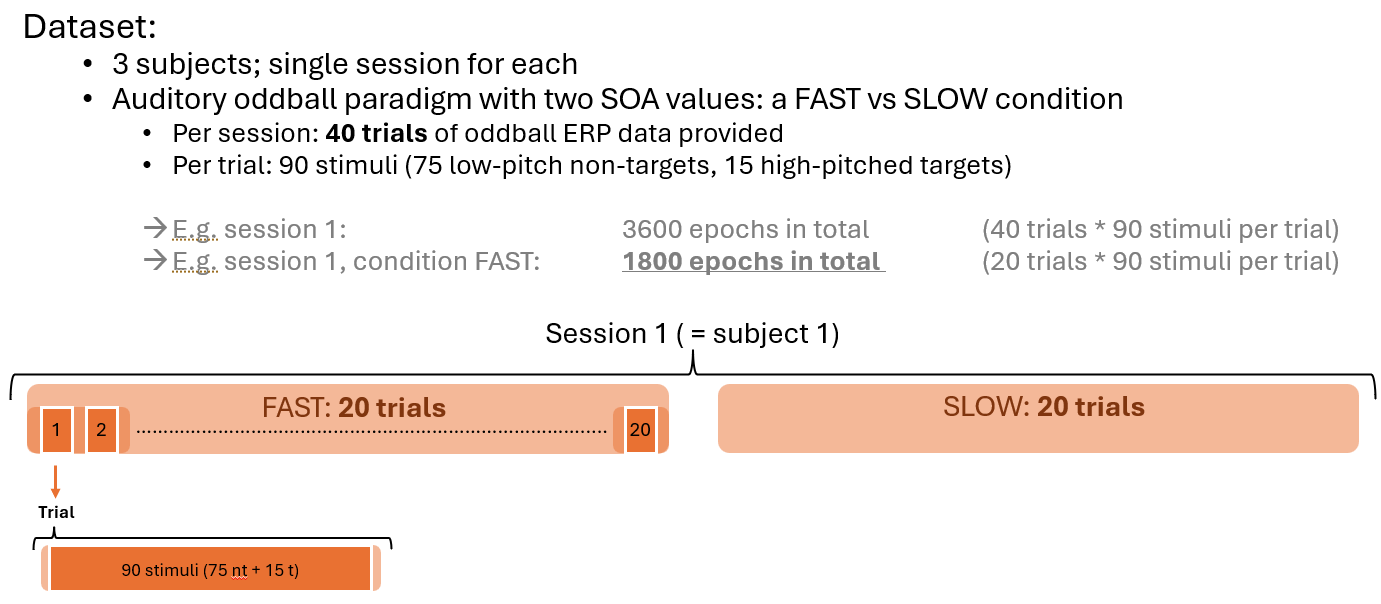

Block-Toeplitz LDA compared to sLDA (with auto shrinkage)


## 7. Assignment 7

### Dataset

## 8. David's MATLAB code

- Running the experiment (manual by David)
- preprocessing 
- sLDA & adaptation

### Running the experiment



=======

For running the experiments, the two important scripts are
* [main_patient_online.m](main_scripts/main_patient_online.m): Runs the online experiments (with feedback)
* [main_patient_presession.m](main_scripts/main_patient_presession.m): Runs the offline experiments (without feedback)

#### Understanding the Matlab Pipeline
=======

Let's have a closed look at the [main_patient_online.m](main_scripts/main_patient_online.m). This essentially controls the online experiments. There are a few parameters that can be changed throughout the training (the words, SOA, condition (headphone vs 6 directions), and difficulty level (p-value of early stopping for BCI-based training) or the thresholds for button-press training).

All other config files are either stored in the [config_global.ini](main_scripts/config_global.ini) (for everything related to the experiment) and in [set_bbciparameters_bp.m](online_functions/set_bbciparameters_bp) or [set_bbciparameters_auditoryAphasia.m](online_functions/set_bbciparameters_auditoryAphasia.m) for the data analysis in the Matlab part for button-press and EEG-based feedback, respectively. Here, BBCI refers to the [Berlin Brain-Computer Interface (BBCI) Toolbox](https://github.com/bbci/bbci_public) which is used to run the online experiments.

In the main online experiments, the next step is to set up the BBCI pipeline (i.e. training a classifier on the previous session) and to initialize the parameters before starting [Pyff](https://github.com/venthur/pyff). Pyff is used to communicate between Matlab and Python. Also the BrainVision Recorder is started which records the EEG signals and merges them with the marker that were sent by the Python application. The markers are specified [here](/app/markers.py).

The experiments has several stages (resting-state, Oddball, familiarization, online experiment, resting-state) that are described in more detail in the [instructions](../documents/experiment_instructions.pdf). In the following, a closer description of the online experiment is provided.

The online experiment is divided into different blocks, runs and trials. Each block contains 6 runs, and each run contains 6 trial. A trial can contain several stimuli (e.g. words), but normally not more than 90. The application always runs without a break for one complete run (~3-4 minutes). During that time, the function [bbci_apply_uni](online_functions/bbci_apply_uni_epoch.m) is called. This function is top-level function of the online paradigms. It permanently waits for new data, identifies relevant events based on the markers, and:
  - computes the features for these intervals: These are normally the average amplitudes for several intervals.
  - classifies the single event based on these features as more likely to be target or more likely to be non-target using a shrinkage-regularized LDA classifier [1]. The results are then integrated over the course of one trial and shown in a visualization.
  - adapts the LDA parameters based on supervised adaptation (pcovmean-adaptation [2])
  - sends classification results to the Python application via [Pyff](https://github.com/venthur/pyff).
This procedure is repeated until the end of a trial (90 stimuli) has been reached. If the signals could very clearly be seperated, then the trial is aborted earlier using dynamic stopping based on a T-Test between the best and second-best class [3]. This is done in [bbci_control_auditoryAphasia](online_functions/bbci_control_auditoryAphasia.m).

Finally, the data of the experiments can be found in D:/data/bbciRaw/VPname_YY_MM_DD.

----

[1] Blankertz, Benjamin, et al. "Single-trial analysis and classification of ERP components—a tutorial." NeuroImage 56.2 (2011): 814-825.

[2] Vidaurre, Carmen, et al. "Toward unsupervised adaptation of LDA for brain–computer interfaces." IEEE Transactions on Biomedical Engineering 58.3 (2011): 587-597.

[3] Höhne J, Schreuder M, Blankertz B and Tangermann M 2010 Two-dimensional auditory P300 speller with predictive text system Proc. IEEE Conf. of Engineering in Medicine and Biology Society pp 4185–8


@David Hübner, 3.2019.


### Preprocessing

.

## 9. Available adaptation

### Simon's adaptation strategy

In [ ]:
# Simon's

def adaptation(self, X, y, eta_cov = 0.001, eta_mean = 0.005):
        """
        Calculate new w and b by adaptation method proposed by Vidaurre et al.(2011)[1]

        Parameters
        ----------
        X : {array-like} of shape (n_samples, n_features)
            The feature matrix to be feeded for adaptation.


        [1] Vidaurre et al. Toward Unsupervised Adaptation of LDA for Brain_Computer Interfaces. (2011)
        
        """
        
        y_train = np.append(self.y_train, y)
        C_inv = self.C_inv
        cl_mean = self.cl_mean

        for idx, cl in enumerate(y):
            
            x = X[idx, :]
            x = x.reshape((x.size, 1))

            # Covariance adaptation
            v = np.dot(C_inv, x)
            
            frac_num = np.dot(v, v.T)
            frac_den = ((1 - eta_cov)/eta_cov) + np.dot(x.T, v)
            
            I = C_inv - (frac_num / frac_den)
            C_inv = I / (1 - eta_cov)

            # Class mean adaptation
            class_idx = np.where(self.classes_ == cl)[0]
            
            shape = cl_mean[:, class_idx].shape

            cl_mean[:,class_idx] = (1-eta_mean)*cl_mean[:,class_idx] + (eta_mean*x)
         
            
        if self.priors is None:
            # here we deviate from the bbci implementation and
            # use the sample priors by default
            _, y_t = np.unique(y_train, return_inverse=True)  # non-negative ints
            priors = np.bincount(y_t) / float(len(y))
        else:
            priors = self.priors
        prior_offset = np.log(priors)

        self.C_inv = C_inv
        self.cl_mean = cl_mean
        self.y_train = y_train
        self.prior_offset = prior_offset
    
    def apply_adaptation(self):

        w = np.dot(self.C_inv, self.cl_mean)
        w = w / np.linalg.norm(w) if self.unit_w else w
        b = -0.5 * np.sum(self.cl_mean * w, axis=0).T + self.prior_offset

        self.coef_ = w.T
        self.intercept_ = b
